# Portfolio Risk Simulation


---

Author: José Reyes

Probability of Default Modeling

**Difficulty**

🟡 Intermediate

**Estimated Reading Time**

45–60 minutes

**Prerequisites**

- Notebook 01 — Credit Scoring Fundamentals
- Notebook 02 — Building an Educational Credit Score
- Notebook 03 — Probability of Default

---

In the previous notebooks we learned how to evaluate an individual customer using:

- Educational Credit Score
- Probability of Default (PD)

In this notebook we shift our perspective.

Instead of analyzing one customer at a time, we will simulate an entire credit portfolio and evaluate its overall risk profile, just as a Credit Risk team would do in a financial institution.

## Educational Note

This notebook does **not** introduce a new mathematical model.

Instead, it integrates the models developed throughout the previous notebooks.

We will reuse:

- Credit Score Model
- Probability of Default Model
- Portfolio Generator

to analyze a complete customer portfolio.

Although the portfolio is synthetically generated, the workflow closely resembles how analysts evaluate retail lending portfolios in banks and financial institutions.

## 1. Learning Objectives

After completing this notebook you will be able to:

- Generate an educational credit portfolio.
- Estimate the Credit Score for every customer.
- Calculate the Probability of Default (PD).
- Classify customers according to their credit risk.
- Analyze the portfolio using business-oriented KPIs.
- Visualize the overall risk profile of the portfolio.

## 2. Business Context

Imagine you work as a Credit Risk Analyst at a financial institution.

Thousands of customers already have active loans.

At this point, evaluating individual customers is no longer enough.

Management wants answers to questions such as:

- How risky is our portfolio?
- Which customers represent the highest risk?
- How many customers belong to each risk segment?
- What is the average Probability of Default?
- Is the portfolio becoming riskier over time?

These questions are answered through **Portfolio Risk Analysis**.

## 2. Why Portfolio Analysis Matters

Every approved loan contributes to the institution's total credit exposure.

Even if each individual loan appears acceptable, the overall portfolio may become excessively risky if many high-risk customers accumulate over time.

Portfolio analysis allows financial institutions to:

- Monitor portfolio quality.
- Identify risk concentrations.
- Support lending strategies.
- Estimate expected losses.
- Make better business decisions.

Rather than focusing on one customer, analysts evaluate the portfolio as a whole.

## 3. Project Architecture

The notebook contains only the educational workflow.

Business logic is implemented inside reusable modules located in the `src` directory.

```text
src/

portfolio_generator.py

credit_score.py

pd_model.py
```

This separation allows the same code to be reused across future projects and applications.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from src.portfolio_generator import generate_customers

from src.credit_score import (
    calculate_raw_score,
    normalize_credit_score
)

from src.pd_model import (
    probability_of_default,
    classify_pd
)

### Step 1: Generating the Portfolio

Rather than manually entering customer information, we will generate an educational portfolio containing 500 synthetic customers.

The portfolio generator creates realistic credit profiles using probability distributions inspired by retail banking behavior.

Each customer includes:

- Late Payments
- Credit Utilization
- Credit History
- Credit Mix
- Recent Credit Inquiries

These variables will later be used to estimate both the Credit Score and the Probability of Default.

In [7]:
customers = generate_customers(
    n_customers=500,
    random_state=42
)

In [8]:
customers.head()

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries
0,C0001,0,51.15,11,3,4
1,C0002,4,78.77,8,3,0
2,C0003,2,62.11,11,1,1
3,C0004,1,34.62,13,2,0
4,C0005,0,28.83,12,1,1


Although these customers are synthetically generated, they resemble the type of structured data commonly available within financial institutions.

Each row represents a single customer, while each column describes one aspect of that customer's credit profile.

From this point onward, we will progressively enrich the dataset by estimating additional risk metrics such as Credit Score and Probability of Default.

In [9]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    str    
 1   Late_Payments         500 non-null    int64  
 2   Credit_Utilization    500 non-null    float64
 3   Credit_History_Years  500 non-null    int64  
 4   Credit_Mix            500 non-null    int64  
 5   Recent_Inquiries      500 non-null    int64  
dtypes: float64(1), int64(4), str(1)
memory usage: 23.6 KB


In [10]:
customers.describe()

,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries
count,500.00000,500.000000,500.000000,500.000000,500.000000
mean,1.12400,45.137300,9.346000,2.306000,1.082000
std,1.32368,18.127285,3.919823,0.884267,1.256357
min,0.00000,-3.540000,1.000000,1.000000,0.000000
25%,0.00000,33.285000,7.000000,2.000000,0.000000
50%,1.00000,44.410000,9.000000,2.000000,1.000000
75%,2.00000,56.900000,12.000000,3.000000,2.000000
max,5.00000,100.420000,19.000000,4.000000,5.000000


The summary statistics provide an initial overview of the portfolio.

For example, we can observe:

- The average credit utilization.
- The distribution of late payments.
- Typical credit history lengths.
- The range of customer characteristics.

These descriptive statistics serve as a baseline before introducing the Credit Score model.

**From Customer Data to Portfolio Analytics**

The generated dataset currently contains only customer characteristics.

To evaluate portfolio risk, we must estimate additional business metrics for every customer.

Throughout this section we will progressively enrich the portfolio by calculating:

- Raw Credit Score
- Credit Score
- Probability of Default (PD)
- Risk Category

These variables will later serve as the foundation for portfolio-level analysis.

### Step 2: Estimating the Credit Score

The first step consists of applying the Educational Credit Score model developed in Notebook 02.

Rather than manually evaluating customers one by one, we can apply the same model across the entire portfolio.

This demonstrates one of the main advantages of reusable business modules: a single function can evaluate hundreds or even thousands of customers consistently.

In [11]:
# Generating the raw score for each customer
customers["Raw_Score"] = (customers.apply(calculate_raw_score, axis=1))
customers.head()

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score
0,C0001,0,51.15,11,3,4,79.00
1,C0002,4,78.77,8,3,0,44.50
2,C0003,2,62.11,11,1,1,72.25
3,C0004,1,34.62,13,2,0,86.50
4,C0005,0,28.83,12,1,1,93.00


The Raw Score is an intermediate value produced by our educational scoring model.

Although useful internally, financial institutions rarely communicate raw scores directly.

Instead, they transform them into standardized Credit Scores that are easier to interpret and compare across customers.

In [13]:
# Generating the Credit Score based on Raw Score
customers["Credit_Score"] = (customers["Raw_Score"].apply(normalize_credit_score))
customers.head()

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score,Credit_Score
0,C0001,0,51.15,11,3,4,79.00,756
1,C0002,4,78.77,8,3,0,44.50,600
2,C0003,2,62.11,11,1,1,72.25,725
3,C0004,1,34.62,13,2,0,86.50,789
4,C0005,0,28.83,12,1,1,93.00,818


Every customer now has a standardized Credit Score ranging approximately from **400 to 850**.

This score summarizes the customer's overall credit quality and will become one of the primary inputs for estimating Probability of Default.

### Step 3: Estimating the Probability of Default

The next step is estimating the Probability of Default (PD).

Using the reusable functions created in `src/pd_model.py`, we calculate the expected probability that each customer will fail to repay their loan obligations.

Although our coefficients are educational, the workflow mirrors the methodology commonly used by financial institutions.

In [14]:
# Generating a simulated probability of default based on the credit_score variables
customers["Probability_of_Default"] = (customers.apply(probability_of_default, axis=1))
customers.head()

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score,Credit_Score,Probability_of_Default
0,C0001,0,51.15,11,3,4,79.00,756,0.086329
1,C0002,4,78.77,8,3,0,44.50,600,0.338018
2,C0003,2,62.11,11,1,1,72.25,725,0.179164
3,C0004,1,34.62,13,2,0,86.50,789,0.052808
4,C0005,0,28.83,12,1,1,93.00,818,0.045172


Each customer now has an estimated Probability of Default.

Higher values indicate greater expected credit risk.

Rather than replacing the Credit Score, the Probability of Default complements it by expressing credit quality as an intuitive probability between **0 and 1**.

### Step 4: Risk Classification

Business users rarely work directly with probabilities.

Instead, customers are grouped into qualitative risk categories that simplify communication and decision-making.

Using our educational model, every customer will be assigned to one of five risk levels.

In [15]:
# Based on the PD, we will use the classify_pd to label each customer into a category
customers["Risk_Category"] = (customers["Probability_of_Default"].apply(classify_pd))
customers.head()

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score,Credit_Score,Probability_of_Default,Risk_Category
0,C0001,0,51.15,11,3,4,79.00,756,0.086329,Low
1,C0002,4,78.77,8,3,0,44.50,600,0.338018,High
2,C0003,2,62.11,11,1,1,72.25,725,0.179164,Medium
3,C0004,1,34.62,13,2,0,86.50,789,0.052808,Low
4,C0005,0,28.83,12,1,1,93.00,818,0.045172,Very Low


The portfolio now contains both quantitative and qualitative risk information.

This enriched dataset resembles the type of customer-level information frequently analyzed by Credit Risk teams before preparing portfolio reports.

## 4. Portfolio Preview (KPI's)

Our portfolio has evolved from a simple customer dataset into a risk analytics dataset.

Each customer now includes:

- Customer profile
- Credit Score
- Probability of Default
- Risk Category

The next step is to summarize this information using portfolio-level Key Risk Indicators (KRIs).

In [16]:
customers.head(10)

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score,Credit_Score,Probability_of_Default,Risk_Category
0,C0001,0,51.15,11,3,4,79.00,756,0.086329,Low
1,C0002,4,78.77,8,3,0,44.50,600,0.338018,High
2,C0003,2,62.11,11,1,1,72.25,725,0.179164,Medium
3,C0004,1,34.62,13,2,0,86.50,789,0.052808,Low
4,C0005,0,28.83,12,1,1,93.00,818,0.045172,Very Low
5,C0006,0,53.85,11,3,0,86.00,787,0.046058,Very Low
6,C0007,0,21.24,13,2,0,96.00,832,0.027447,Very Low
7,C0008,3,77.97,14,3,1,58.75,664,0.223300,Medium
8,C0009,1,66.23,15,1,0,78.50,753,0.093820,Low
9,C0010,2,36.55,12,1,0,79.25,757,0.098669,Low


At this point we have successfully evaluated every customer individually.

However, Credit Risk Managers rarely inspect customers one by one.

Instead, they monitor portfolio-wide indicators that summarize the overall health of the lending portfolio.

The next section introduces several Key Risk Indicators (KRIs) commonly used to monitor portfolio quality.

In [44]:
# We will save the generated dataframe because we will use it further in Notebook 5
customers.to_csv("../data/customers.csv", index=False)

## 5. Portfolio Key Risk Indicators (KRIs)

Now that every customer has been evaluated, we can summarize the overall portfolio using Key Risk Indicators (KRIs).

Unlike customer-level metrics, KRIs provide a high-level overview of portfolio quality and support strategic decision-making.

Throughout this section we will calculate several indicators commonly monitored by Credit Risk teams.

### KPI 1: Total Customers

The first indicator simply measures the portfolio size.

Although straightforward, portfolio size provides important context for interpreting the remaining metrics.

In [17]:
total_customers = len(customers)
print(f"Total Customers: {total_customers}")

Total Customers: 500


Portfolio size determines the scale of the institution's customer base.
All subsequent indicators should be interpreted relative to this value.

### KPI 2: Average Credit Score

Rather than inspecting individual scores, analysts often monitor the average Credit Score across the portfolio.

A higher average generally indicates a healthier customer base.

In [18]:
average_score = customers["Credit_Score"].mean()
print(f"Average Credit Score: {average_score:.2f}")

Average Credit Score: 755.82


Changes in the average Credit Score may indicate improvements or deterioration in portfolio quality over time.

### KPI 3: Average Probability of Default

The Probability of Default can also be summarized across the entire portfolio.

This indicator estimates the average expected default probability among all customers.

In [19]:
average_pd = customers["Probability_of_Default"].mean()
print(f"Average PD: {average_pd:.2%}")

Average PD: 10.87%


A lower average Probability of Default generally indicates lower expected portfolio risk.

Risk managers continuously monitor this metric to detect changes in portfolio quality.

### KPI 5: Average Credit Utilization

Credit Utilization is an important measure of customer leverage.

Higher utilization may indicate greater financial stress.

In [20]:
average_utilization = customers["Credit_Utilization"].mean()
print(f"Average Utilization: {average_utilization:.2f}%")

Average Utilization: 45.14%


Very high portfolio utilization may signal increasing financial pressure among borrowers.

### KPI 5: Average Late Payments

Late payments provide a direct measure of customer payment behavior.

Monitoring the portfolio average helps identify changes in repayment quality.

In [21]:
average_late = customers["Late_Payments"].mean()
print(f"Average Late Payments: {average_late:.2f}")

Average Late Payments: 1.12


An increasing average number of late payments often precedes higher portfolio credit risk.

### KPI 6: Customers by Risk Category

Individual probabilities are useful for analysts.

Business managers often prefer understanding how customers are distributed across qualitative risk segments.

In [22]:
risk_distribution = (customers["Risk_Category"].value_counts().sort_index())
risk_distribution

Risk_Category
High         18
Low         304
Medium       86
Very Low     92
Name: count, dtype: int64

Risk segmentation provides a quick overview of portfolio composition.

A portfolio concentrated in Low and Very Low risk categories is generally considered healthier than one dominated by High Risk customers.

### KPI 7: Highest Risk Customer

Analysts frequently identify customers with the greatest estimated default probability for closer monitoring.

In [31]:
highest_risk = customers.loc[customers["Probability_of_Default"].idxmax()] # idxmax() returns the filtered customer ID to search with .iloc
highest_risk

Customer_ID                  C0051
Late_Payments                    4
Credit_Utilization           74.32
Credit_History_Years             5
Credit_Mix                       1
Recent_Inquiries                 1
Raw_Score                     39.5
Credit_Score                   578
Probability_of_Default    0.469478
Risk_Category                 High
Name: 50, dtype: object

High-risk customers may require additional monitoring, stricter lending conditions, or proactive risk mitigation strategies.

### KPI 8: Lowest Risk Customer

Likewise, institutions often identify their strongest customers.

These borrowers may qualify for premium financial products or preferential lending conditions.

In [32]:
lowest_risk = customers.loc[customers["Probability_of_Default"].idxmin()] # Same as above but "idxmin()"
lowest_risk

Customer_ID                  C0348
Late_Payments                    0
Credit_Utilization           14.35
Credit_History_Years            19
Credit_Mix                       2
Recent_Inquiries                 0
Raw_Score                     96.0
Credit_Score                   832
Probability_of_Default    0.018133
Risk_Category             Very Low
Name: 347, dtype: object

Customers with very low expected default probabilities represent attractive lending opportunities and often receive the most competitive financial products.

### KPI 9: Expected Defaults

One interesting interpretation of Probability of Default is that the sum of all individual PD values approximates the expected number of customers who may default.

Although simplified, this concept provides an intuitive portfolio-level estimate of expected credit losses.

In [33]:
expected_defaults = (customers["Probability_of_Default"].sum())
print(f"Expected Defaults: {expected_defaults:.2f}")

Expected Defaults: 54.33


For example, an Expected Defaults value of **18.4** suggests that, on average, approximately 18 customers would be expected to default under the assumptions of this educational model.

It is important to remember that this represents an expected value rather than an exact prediction.

### Portfolio Dashboard

The indicators calculated throughout this section can now be combined into a concise executive summary.

Rather than reviewing each metric separately, decision-makers often rely on dashboards that provide an integrated view of portfolio health.

In [34]:
portfolio_dashboard = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Average Credit Score",
        "Average PD",
        "Average Utilization",
        "Average Late Payments",
        "Expected Defaults"
    ],
    "Value": [
        total_customers,
        round(average_score, 2),
        f"{average_pd:.2%}",
        f"{average_utilization:.2f}%",
        round(average_late, 2),
        round(expected_defaults, 2)
    ]
})

portfolio_dashboard

,Metric,Value
0,Total Customers,500
1,Average Credit Score,755.82
2,Average PD,10.87%
3,Average Utilization,45.14%
4,Average Late Payments,1.12
5,Expected Defaults,54.33


This dashboard summarizes the most important characteristics of the portfolio.

In practice, similar dashboards are reviewed periodically by Credit Risk Managers to monitor portfolio quality, identify emerging risks, and support strategic lending decisions.

## 6. Visualizing Portfolio Risk

Numerical indicators provide valuable information, but visualizations often reveal patterns that are difficult to identify from tables alone.

In this section we will explore the portfolio using several charts commonly employed in business analytics and credit risk reporting.

Each visualization highlights a different aspect of portfolio quality.

### 📊 Visualization 1: Credit Score Distribution

The **Credit Score Distribution** summarizes the creditworthiness of every customer.

By visualizing its distribution, we can quickly determine whether the portfolio is dominated by strong borrowers or contains a significant proportion of higher-risk customers.

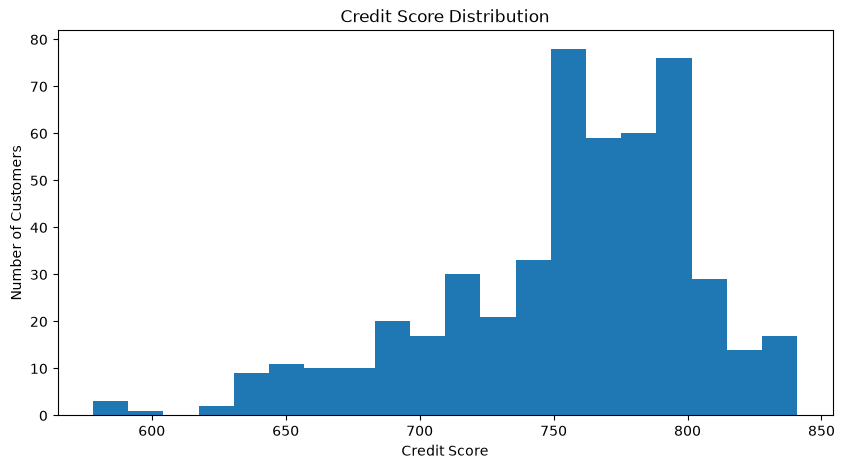

In [35]:
# Making the Histogram

# Design
plt.figure(figsize=(10,5))
plt.hist(customers["Credit_Score"], bins=20)

# Titles and Labels
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.show()

A portfolio concentrated around higher Credit Scores generally indicates stronger overall customer quality.

Conversely, a distribution skewed toward lower scores may suggest increasing portfolio risk and could require stricter lending policies.

### 📊 Visualization 2: Probability of Default Distribution

While the Credit Score provides a standardized measure of credit quality, the Probability of Default expresses risk directly as an estimated likelihood of default.

Understanding its distribution helps analysts identify whether portfolio risk is concentrated or broadly dispersed.

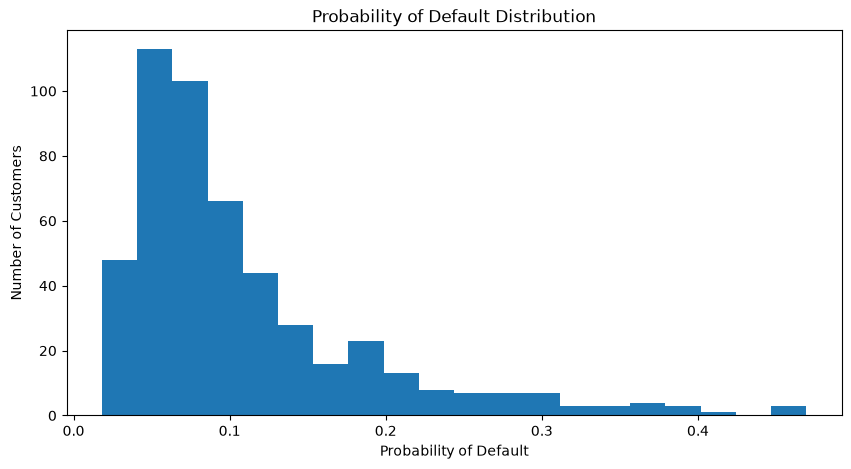

In [36]:
# Making the Histogram

# Design
plt.figure(figsize=(10,5))
plt.hist(customers["Probability_of_Default"], bins=20)

# Titles and Labels
plt.title("Probability of Default Distribution")
plt.xlabel("Probability of Default")
plt.ylabel("Number of Customers")

plt.show()

Most healthy retail portfolios are expected to contain a large proportion of customers with relatively low default probabilities.

A long right tail may indicate a subset of customers requiring closer monitoring.

### 📊 Visualization 3: Risk Category Distribution

Risk categories simplify portfolio reporting by grouping customers according to their estimated default probability.

This visualization provides a high-level overview of portfolio composition.

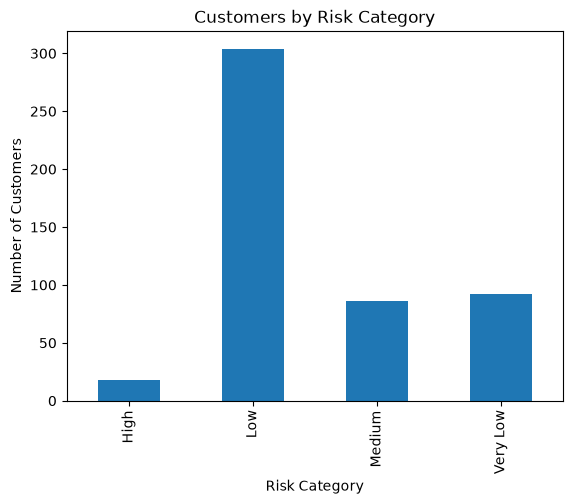

In [37]:
# Making the Bar Chart

# Turning the Dataframe into a bar chart
risk_distribution.plot(kind="bar")

# Titles and Labels
plt.title("Customers by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

plt.show()

Ideally, most customers should belong to the Very Low or Low risk categories.

A growing proportion of High Risk customers may signal deteriorating portfolio quality.

### 📊 Visualization 4: Credit Score vs Probability of Default

One of the most important relationships in Credit Risk is the inverse relationship between Credit Score and Probability of Default.

Although our educational model uses manually calibrated coefficients, the resulting pattern reflects the intuition behind real-world credit risk models.

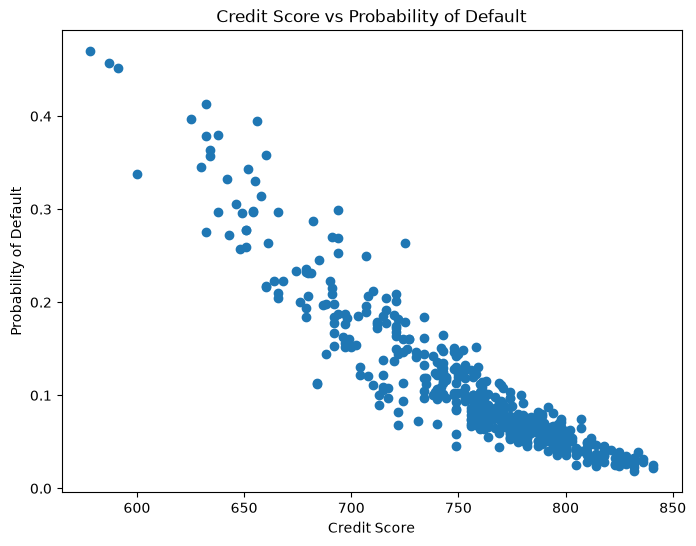

In [38]:
# Making the scatterplot

plt.figure(figsize=(8,6))
plt.scatter(customers["Credit_Score"], customers["Probability_of_Default"])

plt.title("Credit Score vs Probability of Default")
plt.xlabel("Credit Score")
plt.ylabel("Probability of Default")

plt.show()

Customers with stronger Credit Scores generally exhibit lower default probabilities.

Conversely, customers with weaker credit profiles tend to present substantially higher expected risk.

This inverse relationship forms the foundation of many modern credit risk models.

### 📊 Visualization 5: Portfolio Composition

Pie charts provide an intuitive representation of portfolio composition.

Rather than focusing on individual customers, this chart emphasizes the relative weight of each risk segment within the overall portfolio.

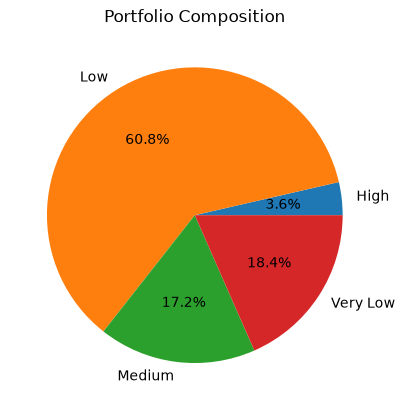

In [39]:
# Making the pie chat with the risk dist.

risk_distribution.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Portfolio Composition")

plt.show()

As said before... A portfolio dominated by low-risk customers generally indicates a conservative lending strategy.

Conversely, a large concentration of High Risk customers may increase expected losses during periods of economic stress.

### 📊 Visualization 6: Probability of Default Boxplot

While averages summarize the portfolio, they may hide important variability.

A boxplot allows analysts to evaluate the spread of Probability of Default values and identify unusually risky customers.

D:\AppData\Local\Temp\ipykernel_29632\3507057498.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(customers["Probability_of_Default"], vert=False)


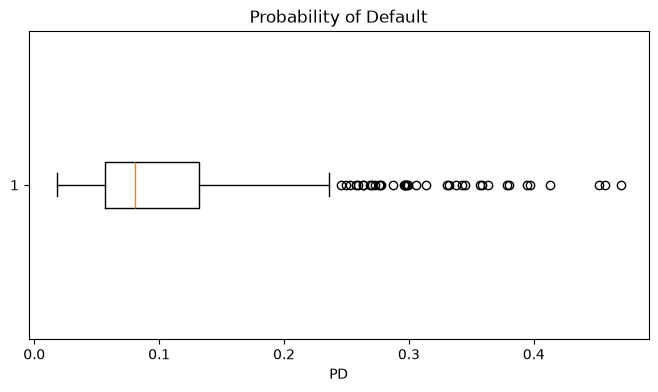

In [40]:
# Making the boxplot

plt.figure(figsize=(8,4))
plt.boxplot(customers["Probability_of_Default"], vert=False)

plt.title("Probability of Default")
plt.xlabel("PD")

plt.show()

A narrow box indicates a relatively homogeneous portfolio.

Outliers may represent customers requiring additional monitoring, revised lending conditions, or closer credit review.

### Portfolio Visualization Summary

Throughout this section we explored the simulated portfolio from multiple perspectives.

The combination of numerical indicators and visualizations provides a comprehensive overview of portfolio quality.

Rather than analyzing individual customers, we have adopted the perspective of a Credit Risk Analyst responsible for monitoring an entire lending portfolio.

## 7. Executive Summary

Throughout this notebook we transitioned from analyzing individual customers to evaluating an entire credit portfolio.

Using the reusable modules developed in previous notebooks, we generated a synthetic portfolio of customers, estimated their Credit Scores, calculated their Probability of Default, and summarized the portfolio using Key Risk Indicators and business-oriented visualizations.

From a business perspective, portfolio-level analytics enables financial institutions to monitor portfolio quality, identify emerging risks, and support strategic lending decisions.

Although the models implemented throughout this project are educational, the analytical workflow closely resembles the reporting process performed by Credit Risk teams in banks and lending institutions.

## 8. Key Takeaways

After completing this notebook, you should now understand:

- Why portfolio analysis is more informative than evaluating customers individually.
- How Credit Scores and Probability of Default can be aggregated across an entire portfolio.
- How Key Risk Indicators (KRIs) summarize portfolio quality.
- Why visualizations play an essential role in communicating portfolio risk.
- How reusable business modules simplify financial analytics workflows.

These concepts form the foundation of modern Credit Risk Management.

## 9. From Theory to Practice

Throughout this notebook we implemented simplified educational models.

In real financial institutions, however, portfolio analysis typically involves:

- Millions of customer records.
- Historical repayment behavior.
- Loan characteristics.
- Macroeconomic variables.
- Machine Learning and statistical models.
- Regulatory frameworks such as Basel III and IFRS 9.

Despite these differences, the analytical workflow remains remarkably similar:

    Customer Data -> Risk Models -> Portfolio Metrics -> Business Decisions

Learning the simplified workflow first makes it much easier to understand how industrial-scale credit risk systems operate.

## 10. What We Built

At this point, our educational Credit Risk package already includes:

```text
src/
    portfolio_generator.py
    credit_score.py
    pd_model.py
```

Together, these modules allow us to:

- Generate synthetic customer portfolios.
- Estimate Credit Scores.
- Calculate Probability of Default.
- Classify customer risk.
- Analyze portfolio-level metrics.

This modular architecture mirrors how analytical code is organized in professional data science projects.